##### Author: Jimin Kim (jk55@uw.edu)
##### Version 1.9.0

# Lab 4 Report

## Group Members: Sparsh Dadhich, Sam Decker
## Group Name for Leaderboard:

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [10]:
from IPython.display import Image as ipyimage #For displaying images in colab jupyter cell

### Exercise 1: Construct Dictionaries from Data

In [12]:
def convert_csv_to_dict(file_path):

    # YOUR CODE HERE
    # Section 1.1 and 2.3 of Lab4_Lecture_Examples.ipynb might be helpful

    data = pd.read_csv(file_path) # Read the CSV file

    filename = file_path.split('/')[-1] # Extract filename from the file_path

    dict_object = {'Filename': filename} # Initialize the dictionary with the filename

    # Loop over each column in the data and add to the dictionary
    for column in data.columns:
      dict_object[column] = data[column].tolist()

    return dict_object

In [13]:
TSLA_dict = convert_csv_to_dict('TSLA.csv')

In [14]:
# Navigate to keys corresponding to 2nd and 4th columns (Open and Low prices) of TSLA.csv,
# Print first 10 elements of each key.

TSLA_column2 = "Open"
TSLA_column4 = "Low"
print(TSLA_dict[TSLA_column2][:10])
print(TSLA_dict[TSLA_column4][:10])

[19.0, 25.790001, 25.0, 23.0, 20.0, 16.4, 16.139999, 17.58, 17.950001, 17.389999]
[17.540001, 23.299999, 20.27, 18.709999, 15.83, 14.98, 15.57, 16.549999, 17.0, 16.9]


In [15]:
diabetes_dict = convert_csv_to_dict('diabetes.csv')

In [16]:
# Navigate to keys corresponding to 2nd and 4th columns (Glucose and SkinThickness) of diabetes.csv,
# Print first 10 elements of each key.

diabetes_column2 = "Glucose"
diabetes_column4 = "SkinThickness"
print(diabetes_dict[diabetes_column2][:10])
print(diabetes_dict[diabetes_column4][:10])

[148, 85, 183, 89, 137, 116, 78, 115, 197, 125]
[35, 29, 0, 23, 35, 0, 32, 0, 45, 0]


### Exercise 2: Bar graph with confidence intervals

In [18]:
# Load diabetes.csv
# Split the data into diabetic and non-diabetic

diabetes = pd.read_csv('diabetes.csv')
# YOUR CODE HERE

non_diabetic_data = diabetes[diabetes['Outcome'] == 0]
diabetic_data = diabetes[diabetes['Outcome'] == 1]

In [19]:
# Extract glucose, blood pressure, and BMI metrics from diabetic and non-diabetic

# non-diabetic metrics
non_diabetic_glucose = non_diabetic_data['Glucose']
non_diabetic_bp = non_diabetic_data['BloodPressure']
non_diabetic_bmi = non_diabetic_data['BMI']

# diabetic metrics
diabetic_glucose = diabetic_data['Glucose']
diabetic_bp = diabetic_data['BloodPressure']
diabetic_bmi = diabetic_data['BMI']

non_diabetic_list = [non_diabetic_glucose, non_diabetic_bp, non_diabetic_bmi]
diabetic_list = [diabetic_glucose, diabetic_bp, diabetic_bmi]

non_diabetic_bar_labels = ['non_diabetic_glucose', 'non_diabetic_bp', 'non_diabetic_bmi']
diabetic_bar_labels = ['diabetic_glucose', 'diabetic_bp', 'diabetic_bmi']

In [20]:
def produce_bargraph_CI(data_vec_list, conf_level, bar_labels):

    # YOUR CODE HERE
    # THE FUNCTION SHOULD OUTPUT THE PLOT
    # MAKE SURE YOUR LABELS (bar labels, plot titles are large enough)
    z_scores = {0.9: 1.645, 0.95: 1.96, 0.99: 2.576}
    means = [np.mean(data) for data in data_vec_list]
    std_errs = [np.std(data, ddof = 1) / np.sqrt(len(data)) for data in data_vec_list]

    marg_of_errs = [z_scores[conf_level] * std_err for std_err in std_errs]

    # Create the bar graph
    fig = plt.figure(figsize=(5,5))

    plt.bar(bar_labels, means, yerr = marg_of_errs, capsize=8, width = 0.1, color = 'red')
    plt.title('Vitals',fontsize = 10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel('Variables', fontsize =10)
    plt.ylabel('Values', fontsize =10)
    plt.ylim(0, 150)


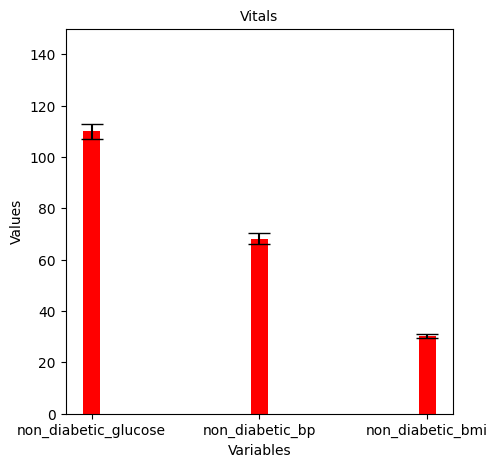

In [21]:
produce_bargraph_CI(data_vec_list = non_diabetic_list, conf_level = 0.99, bar_labels = non_diabetic_bar_labels)

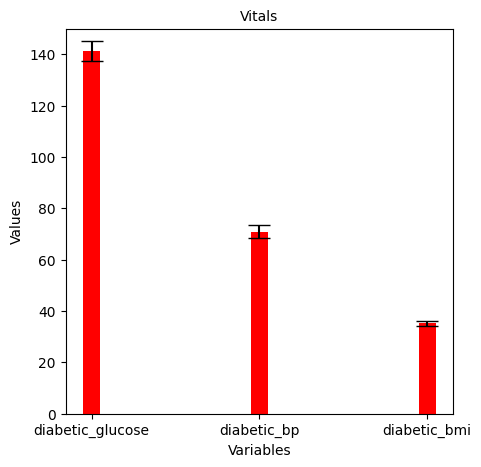

In [22]:
produce_bargraph_CI(data_vec_list = diabetic_list, conf_level = 0.95, bar_labels = diabetic_bar_labels)

### Exercise 3: Rolling Mean/Median Function from Scratch

In [130]:
# Load stock datasets

tesla = pd.read_csv('TSLA.csv')
tesla_np = tesla.to_numpy()

google = pd.read_csv('GOOGL.csv')
google_np = google.to_numpy()

dji = pd.read_csv('DJI.csv')
dji_np = dji.to_numpy()

In [131]:
# Extract closing price for each stock data

tesla_np_closing = tesla_np[:, 4]
google_np_closing = google_np[:, 4]
DJI_np_closing = dji_np[:, 4]

In [132]:
def smooth_data(data_arr, smooth_type, window_size):

    # YOUR CODE HERE
    padded_data_arr = np.pad(data_arr, (window_size -1, 0), mode='constant', constant_values=0) #creates 0 padded version of array
    smoothed_data_arr = np.zeros_like(data_arr, dtype=float) #creates placeholder smooth array to be returned

    i=0
    for i in range(len(data_arr)):
        window_start = i
        window_end = i + (window_size - 1)
        window_data = padded_data_arr[window_start:window_end] #calculates window of values to be processed into mean/median

        if smooth_type == 'mean':
            smoothed_data_arr[i] = np.mean(window_data) #calculates mean of the window and places it into placeholder array
        elif smooth_type == 'median':
            smoothed_data_arr[i] = np.median(window_data) #calculates median of the window and places it into placeholder array

    return smoothed_data_arr

In [133]:
# Tesla closing prices, smooth_type = 'mean', window_size = 100
# Your smoothed data should be the same dimension as the original

smoothed_tsla_closing  = smooth_data(tesla_np_closing, smooth_type = 'mean', window_size = 100)

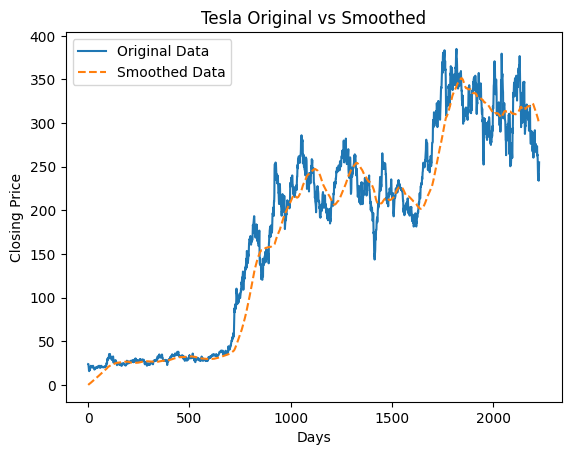

In [134]:
# plot smoothed_tsla_closing on top of tesla_np_closing

# YOUR CODE HERE

plt.plot(tesla_np_closing, label='Original Data', linestyle='-')
plt.plot(smoothed_tsla_closing, label='Smoothed Data', linestyle='--')
plt.title('Tesla Original vs Smoothed')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [135]:
# Google closing prices, smooth_type = 'median', window_size = 150

smoothed_google_closing  = smooth_data(google_np_closing, smooth_type = 'median', window_size = 150)

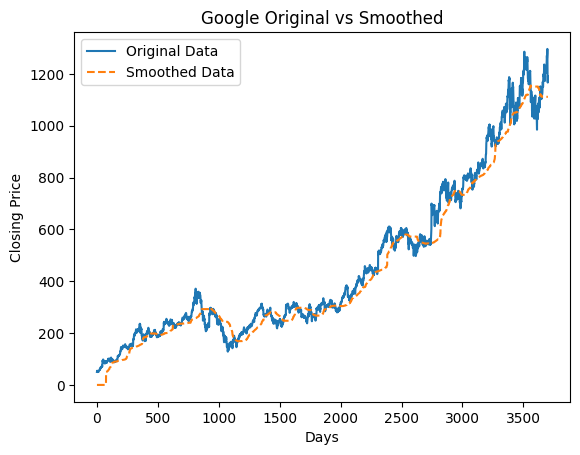

In [136]:
# plot smoothed_google_closing on top of google_np_closing

# YOUR CODE HERE

plt.plot(google_np_closing, label='Original Data', linestyle='-')
plt.plot(smoothed_google_closing, label='Smoothed Data', linestyle='--')
plt.title('Google Original vs Smoothed')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [137]:
# Dow Jones Index closing prices, smooth_type = 'mean', window_size = 200

smoothed_dji_closing  = smooth_data(DJI_np_closing, smooth_type = 'mean', window_size = 200)

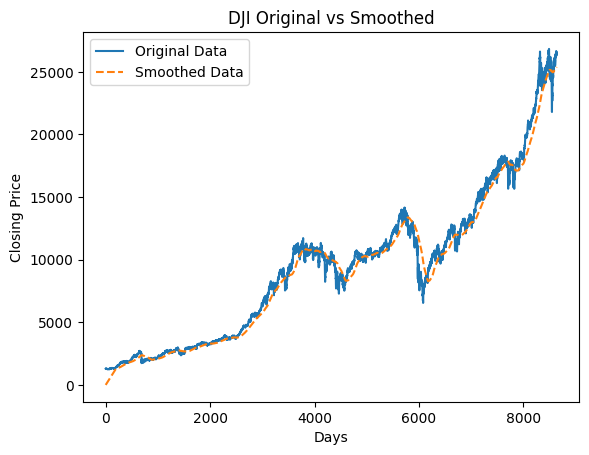

In [138]:
# plot smoothed_dji_closing on top of dji_np_closing

# YOUR CODE HERE

plt.plot(DJI_np_closing, label='Original Data', linestyle='-')
plt.plot(smoothed_dji_closing, label='Smoothed Data', linestyle='--')
plt.title('DJI Original vs Smoothed')
plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

## Extra credit: Code efficiency
### Achieve a runtime speed of < 50ms

In [129]:
timeit -n 1 -r 7 smoothed_google_closing  = smooth_data(google_np_closing, smooth_type = 'median', window_size = 150)

359 ms ± 110 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 4: Ranking Daily Stock Surges/Crashes

In [69]:
date_list_t, price_change_list_t = detect_surge_crash(filepath = 'TSLA.csv, detect_type = 'surge', num_output_dates = 5)

In [74]:
def detect_surge_crash(filepath, detect_type, num_output_dates):
    #reads in file and creates np array
    file = pd.read_csv(filepath)
    file_np = file.to_numpy()
    diff = file_np[:, 4] - file_np[:, 1] #difference between close and open

    if detect_type == 'surge':
        sortedDiff = np.argsort(diff)[::-1] #sorts indices that would sort diff in reverse order (descending)
    if detect_type == 'crash':
        sortedDiff = np.argsort(diff) #sorts indices that would sort array in ascending order

    indexes = sortedDiff[:num_output_dates] #first (k) indices corresponding to max changes
    price_change_list = diff[indexes] #gets values at indexes representing the max prices
    date_list = file_np[indexes, 0] #gets dates associated with the k max/min indices
    return date_list, price_change_list

In [75]:
date_list_t, price_change_list_t = detect_surge_crash(filepath = 'TSLA.csv', detect_type = 'surge', num_output_dates = 5)

In [76]:
print(date_list_t, price_change_list_t)

['2018-08-07' '2018-04-04' '2018-10-23' '2018-12-26' '2018-10-26'] [35.73001099999999 34.16000299999999 30.270019999999988 26.089995999999985
 22.649993999999992]


In [77]:
date_list_g, price_change_list_g = detect_surge_crash(filepath = 'GOOGL.csv', detect_type = 'crash', num_output_dates = 7)

In [78]:
print(date_list_g, price_change_list_g)

['2018-10-29' '2018-10-24' '2018-03-27' '2018-02-08' '2018-12-04'
 '2018-10-10' '2018-12-21'] [-61.81005899999991 -57.88000499999998 -56.96002199999998
 -52.159973000000036 -50.52001900000005 -44.239990000000034
 -40.79003899999998]


## Extra credit: Code efficiency
### Achieve a runtime speed of < 10ms

In [114]:
timeit -n 1 -r 7 date_list_t, price_change_list_t = detect_surge_crash(filepath = 'TSLA.csv', detect_type = 'surge', num_output_dates = 5)

7.83 ms ± 2.55 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### Exercise 5: Human Debugger

### Faulty function #1

In [90]:
def average_data_per_col(arr_2d):

    # NOTE FROM YOUR FRIEND PREPARING FOR STARBUCKS SOFTWARE ENGINEER TECH INTERVIEW
    """  The function takes numpy 2d array as an input, computes mean for each column data, and outputs 1D array
         with the length equal to the # of columns.

         For some reason I keep getting errors.... I need your help to debug the code.
         I need this position so I can get free ice lattes... :(

    """

    # placeholder for averaged values
    averaged_data = ()

    # Loop through each column data to compute mean and append to averaged_data
    for k in range(len(arr_2d[:, 0])):

        averaged_column_data = np.mean(arr_2d[:, k])
        averaged_data.append(averaged_column_data)

    # Return numpy array form of the averaged_data
    return np.array(averaged_data)

In [91]:
# Load diabetes.csv and convert to numpy array

diabetes = pd.read_csv('diabetes.csv')
diabetes_np = diabetes.to_numpy()

In [93]:
# Run faulty function 1

averaged_diabetic_attributes =  average_data_per_col(diabetes_np)

AttributeError: 'tuple' object has no attribute 'append'

In [94]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def average_data_per_col_fixed(arr_2d):

    # YOUR CODE HERE
    averaged_data = [] #changed to an array list

    # Loop through each column data to compute mean and append to averaged_data
    for k in range(arr_2d.shape[1]): #gets num of columns rather than rows

        averaged_column_data = np.mean(arr_2d[:, k])
        averaged_data.append(averaged_column_data)

    # Return numpy array form of the averaged_data
    return np.array(averaged_data)

In [95]:
# Test your fixed function

averaged_diabetic_attributes =  average_data_per_col_fixed(diabetes_np)

In [103]:
# Compare with correct results

correct_result_func1 = np.load('E5_correct_output_1.npy')

# Should return True if the result is correct
np.sum(np.round(correct_result_func1, 3) == np.round(averaged_diabetic_attributes, 3)) == len(correct_result_func1)

True

### Faulty function #2

In [97]:
def daily_stock_change_2_normalized_percentage(opening_price_arr, closing_price_arr):

    # NOTE FROM YOUR FRIEND WHO INVESTED IN TESLA
    """  I want to write a function which takes 2 1D numpy arrays of each corresponding to opening/closing prices of stock
         and output 1D array of daily stock change in percentages.

         I want the percentages scale to be in a scale such that 1 = 100%, -0.5 = -50%, 1.5 = 150%  etc.
         For example, day 1 opening: $10, day 1 closing: $15, change in scaled percecntage: 0.5.

         I am not really getting errors but the numbers don't look right... Can you help me?? :'(

    """

    # placeholder for change percentage values
    change_percentages = np.zeros(len(opening_price_arr), dtype = 'int')

    # Loop through each opening/closing price to compute the change percentage
    for date_num in range(len(opening_price_arr)):

        change_percentages[date_num] = opening_price_arr[date_num] - closing_price_arr[date_num] / opening_price_arr[date_num]

    return change_percentages

In [98]:
# Load tsla.csv and convert to numpy array

tesla = pd.read_csv('TSLA.csv')
tesla_np = tesla.to_numpy()

In [99]:
# Run faulty function 2

change_percentages = daily_stock_change_2_normalized_percentage(tesla_np[:, 1], tesla_np[:, 4])
print(change_percentages)

[ 17  24  24 ... 237 244 242]


In [100]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def daily_stock_change_2_normalized_percentage_fixed(opening_price_arr, closing_price_arr):

    # YOUR CODE HERE
    opening_price_arr = opening_price_arr.astype(float) #ensures that both arrays are floats which can be rounded
    closing_price_arr = closing_price_arr.astype(float)
    #since the parameters are both np arrays, they can be directly subtracted and divided instead of looping over
    change_percentages = (closing_price_arr - opening_price_arr) / opening_price_arr
    return change_percentages

In [101]:
# Test your fixed function

change_percentages = daily_stock_change_2_normalized_percentage_fixed(tesla_np[:, 1], tesla_np[:, 4])
print(change_percentages)

[ 0.25736837 -0.07599848 -0.12160004 ... -0.02026381 -0.00578363
  0.04580496]


In [104]:
# Compare with correct results

correct_result_func2 = np.load('E5_correct_output_2.npy')

# Should return True if the result is correct
np.sum(np.round(correct_result_func2, 3) == np.round(change_percentages, 3)) == len(correct_result_func2)

True

### Faulty function #3

In [105]:
def subset_diabetes_by_age(diabetes_data):

    # NOTE FROM YOUR FRIEND WHO WORKS AT UW IHME
    """ The function takes diabetes pandas data frame as an input and outputs a subplot of 3 x 1 with three histograms.

        Specifically, I want to divide the diabetes data into three age groups -
            1. 20 to 40
            2. 40 to 60
            3. 60 to 80

        and plot 3 histograms of glucose distribution (50 bins per histogram) in 3 x 1 python subplots.

        I seem to be getting error from very beginning even before I divide the dataset....
        My coworkers at IHME prefer R rather than Python... so you are my only hope!

    """

    # Extract the age column of the diabetes_data
    age_column = diabetes_data[:, 8]

    # Construct boolean mask for each age group
    age_20_40_bool_mask = age_column > 20 + age_column < 40
    age_40_60_bool_mask = age_column > 40 + age_column < 60
    age_60_80_bool_mask = age_column > 60 + age_column < 80

    # Get glucose data for each age group via applying the boolean mask for each age group
    age_20_40_glucose = diabetes_data[age_20_40_bool_mask, 2]
    age_40_60_glucose = diabetes_data[age_40_60_bool_mask, 2]
    age_60_80_glucose = diabetes_data[age_60_80_bool_mask, 2]

    # Plot the histogram for each age group in 3 x 1 subplot
    fig = plt.figure(figsize=(15,7))

    plt.subplot(3,1,1)

    plt.hist(age_20_40_glucose, bins = 50)
    plt.title('Age 20 to 40', fontsize = 15)

    plt.subplot(3,1,2)

    plt.hist(age_40_60_glucose, bins = 50)
    plt.title('Age 40 to 60', fontsize = 15)

    plt.subplot(3,1,3)

    plt.hist(age_60_80_glucose, bins = 50)
    plt.title('Age 60 to 80', fontsize = 15)

    plt.tight_layout()

    plt.show()

In [106]:
# Load diabetes.csv as pandas dataframe

diabetes = pd.read_csv('diabetes.csv')

In [107]:
# Run faulty function 3

subset_diabetes_by_age(diabetes_data = diabetes)

InvalidIndexError: (slice(None, None, None), 8)

In [108]:
# YOUR FIXED FUNCTION HERE
# Make sure you comment on your fixes

def subset_diabetes_by_age_fixed(diabetes_data):

    # YOUR CODE HERE
    diabetes_np = diabetes_data.to_numpy() #converts data to np array
    # Extract the age column of the diabetes_data
    age_column = diabetes_np[:, 7] #corrected to age column

    # Construct boolean mask for each age group
    #Switched to and logical operator to include both
    #added inclusive operators
    age_20_40_bool_mask = (age_column >= 20) & (age_column < 40)
    age_40_60_bool_mask = (age_column >= 40) & (age_column < 60)
    age_60_80_bool_mask = (age_column >= 60) & (age_column < 80)

    # Get glucose data for each age group via applying the boolean mask for each age group
    #boolean mask is applied to the np array
    #changed to correct column index for glucoise
    age_20_40_glucose = diabetes_np[age_20_40_bool_mask, 1]
    age_40_60_glucose = diabetes_np[age_40_60_bool_mask, 1]
    age_60_80_glucose = diabetes_np[age_60_80_bool_mask, 1]

    # Plot the histogram for each age group in 3 x 1 subplot
    fig = plt.figure(figsize=(15,7))

    plt.subplot(3,1,1)

    plt.hist(age_20_40_glucose, bins = 50)
    plt.title('Age 20 to 40', fontsize = 15)

    plt.subplot(3,1,2)

    plt.hist(age_40_60_glucose, bins = 50)
    plt.title('Age 40 to 60', fontsize = 15)

    plt.subplot(3,1,3)

    plt.hist(age_60_80_glucose, bins = 50)
    plt.title('Age 60 to 80', fontsize = 15)

    plt.tight_layout()

    plt.show()



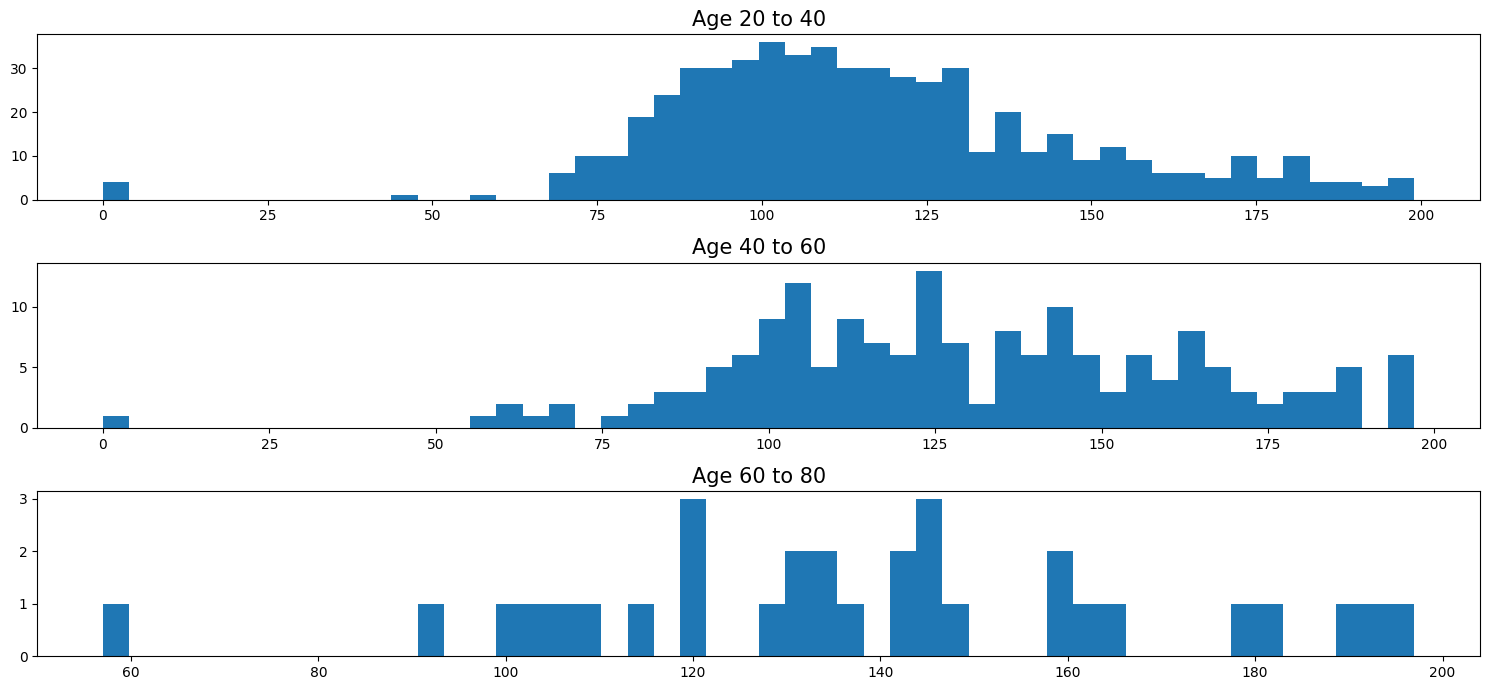

In [109]:
# Test your fixed function
# Compare your plot with the correct plot provided in template folder

subset_diabetes_by_age_fixed(diabetes_data = diabetes)